# Explainability Analysis

This notebook addresses explainability, aiming to clarify the reasoning behind the RankLSTM model's predictions. Rather than focusing solely on performance evaluation, it employs two distinct techniques to analyze input feature importance:

* **Correlation Analysis**: A data-centric, model-agnostic method that examines direct linear relationships between raw input features (such as moving averages) and the target variable (next-day return). This reveals inherent properties of the data.

* **Permutation Feature Importance**: A model-centric approach that probes the trained RankLSTM model to determine which features it depends on most for its predictions. This technique can uncover complex, non-linear relationships learned by the model.

By comparing these methods, the analysis provides insight into whether the model captures straightforward, obvious patterns or identifies more intricate signals within the data.


In [1]:
import matplotlib.pyplot as plt
import argparse
import copy
import numpy as np
import sys
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from time import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('../../'))
from models.lstm import LSTMModel, LSTM
from models.rank_lstm import RankLSTMModel, RankLSTM
from models.rel_rank_lstm import ReRaLSTMModel, ReRaLSTM

## Setup and Model Loading

The necessary data paths are first configured, and the pre-trained `RankLSTM` model for the NASDAQ market is loaded. This model, having already internalized patterns from the training data, serves as the focus of the analysis. The objective is to determine which input features the model deemed most relevant for its predictions.


In [2]:
data_path = '../../data/2013-01-01'
market_name = 'NASDAQ'
tickers_fname = f"{market_name}_tickers_qualify_dr-0.98_min-5_smooth.csv"
parameters = {'seq': 4, 'unit': 64, 'lr': 0.001, 'alpha': 1}

In [3]:
rank_lstm = RankLSTM(
    data_path=data_path,
    market_name=market_name,
    tickers_fname=tickers_fname,
    parameters=parameters,
    steps=1,
    epochs=50,
    batch_size=None,
    gpu=torch.cuda.is_available()
)
rank_lstm_model = rank_lstm.load_model(f'../../data/pretrain/pretrain/{market_name}_ranklstm_model.pt')

#tickers selected: 1026
Raw prices shape: (1026, 1245)
single EOD data shape: (1245, 6)
device: cuda
Model loaded from ../../data/pretrain/pretrain/NASDAQ_ranklstm_model.pt


## Correlation Analysis

The initial analysis investigates the direct linear relationship between each input feature (e.g., 5-day moving average, 10-day moving average) and the target variable (next-day return).

This constitutes a **model-agnostic** approach, revealing the inherent structure of the data prior to any model-based learning. It addresses whether simple, readily observable predictors exist within the raw inputs. The corresponding code flattens the time-series data, computes the Pearson correlation coefficients among all variables, and presents the results as a heatmap for visual clarity.


Method 1: Feature-Target Correlation Analysis


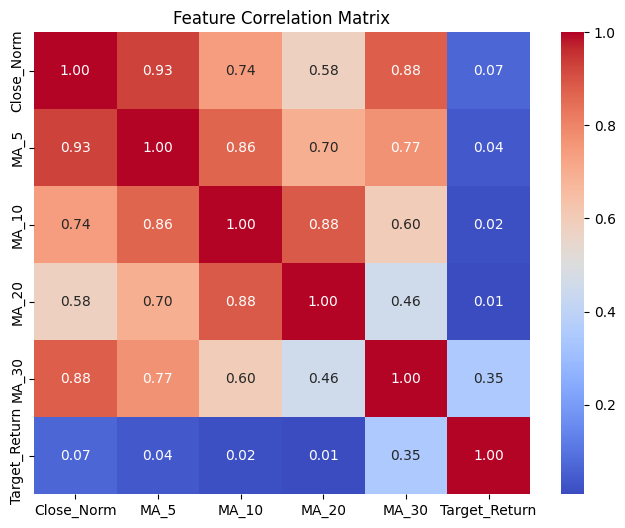


Correlation of each feature with the 1-day return ratio:
Target_Return    1.000000
MA_30            0.346491
Close_Norm       0.068455
MA_5             0.035392
MA_10            0.018464
MA_20            0.008102
Name: Target_Return, dtype: float64


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("="*60)
print("Method 1: Feature-Target Correlation Analysis")
print("="*60)

# flatten the data to perform correlation analysis
eod_data_flat = rank_lstm.eod_data[:, :rank_lstm.valid_index, :].reshape(-1, rank_lstm.fea_dim)
gt_data_flat = rank_lstm.gt_data[:, :rank_lstm.valid_index].reshape(-1, 1)

feature_names = ['Close_Norm', 'MA_5', 'MA_10', 'MA_20', 'MA_30']
df = pd.DataFrame(eod_data_flat, columns=feature_names)
df['Target_Return'] = gt_data_flat

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

# Display the correlation of each feature with the target
print("\nCorrelation of each feature with the 1-day return ratio:")
print(correlation_matrix['Target_Return'].sort_values(ascending=False))

## Permutation feature importance

This technique quantitatively assesses how much the **trained model** depends on each input feature for its predictions. Unlike correlation analysis, it captures non-linear dependencies and feature interactions learned by the model.

The underlying principle is straightforward: if a feature is crucial, then disrupting its informational content—by randomly shuffling its values across the dataset—should degrade model performance. The magnitude of this degradation, measured as an increase in prediction error, serves as an indicator of the feature's importance.

The implemented process follows these steps:

1. Compute the baseline loss on the test set using the original, unaltered data.
2. For each feature, independently shuffle its values while leaving other features intact.
3. Evaluate the model's loss on this perturbed dataset.
4. Record the increase in loss as the feature's importance score.
5. Visualize the importance scores in a bar chart to identify which features the model relies on most.



Method 2: Permutation Feature Importance for RankLSTM (Model-Driven)
Model loaded from ../../data/pretrain/pretrain/NASDAQ_ranklstm_model.pt
Analyzing the trained RankLSTM model.
Baseline Total Loss (MSE + Ranking) on the test set: 0.797196

Permuting feature: Close_Norm...
Permuting feature: MA_5...
Permuting feature: MA_10...
Permuting feature: MA_20...
Permuting feature: MA_30...


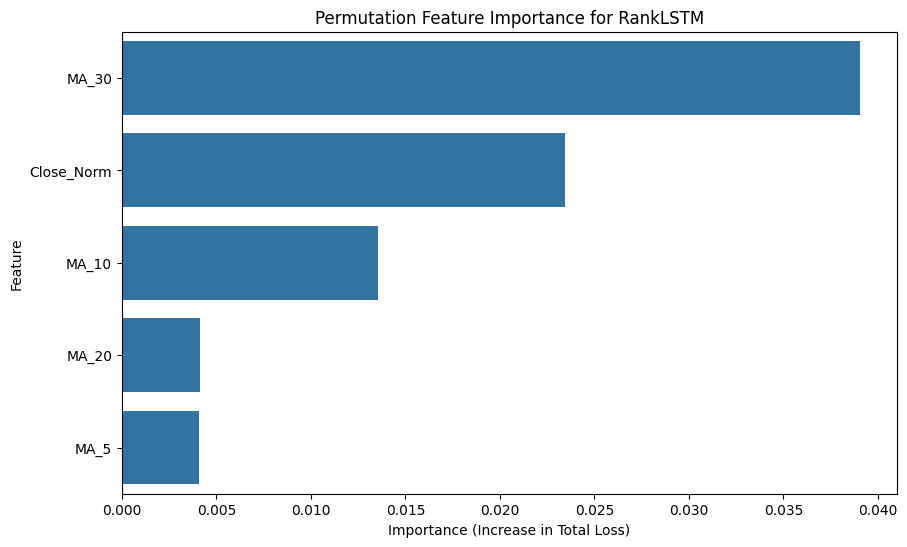


Feature Importances for RankLSTM:
      Feature  Importance (Increase in Total Loss)
4       MA_30                             0.039051
0  Close_Norm                             0.023430
2       MA_10                             0.013567
3       MA_20                             0.004120
1        MA_5                             0.004079


In [6]:
print("\n" + "="*60)
print("Method 2: Permutation Feature Importance for RankLSTM (Model-Driven)")
print("="*60)

# Load the trained RankLSTM model
model_to_explain = rank_lstm.load_model(f'../../data/pretrain/pretrain/{market_name}_ranklstm_model.pt')
print("Analyzing the trained RankLSTM model.")

# Define test period parameters
test_start_index = rank_lstm.test_index
seq_len = rank_lstm.parameters['seq']
steps = rank_lstm.steps
alpha = rank_lstm.parameters['alpha']
device = rank_lstm.device
num_test_steps = rank_lstm.trade_dates - test_start_index - seq_len - steps + 2

# Calculate baseline performance (Total Loss) on the test set
baseline_total_loss = 0.0
with torch.no_grad():
    for i in range(test_start_index - seq_len - steps + 1,
              rank_lstm.trade_dates - seq_len - steps + 1):
        eod_batch, mask_batch, price_batch, gt_batch = rank_lstm.get_batch(i)
        x = torch.tensor(eod_batch, dtype=torch.float32, device=device)
        mask = torch.tensor(mask_batch, dtype=torch.float32, device=device)
        base_price = torch.tensor(price_batch, dtype=torch.float32, device=device)
        gt = torch.tensor(gt_batch, dtype=torch.float32, device=device)
        pred = model_to_explain(x)
        total_loss, _, _, _ = rank_lstm.compute_losses(pred, base_price, gt, mask, alpha)
        baseline_total_loss += total_loss.item()
        
baseline_total_loss /= num_test_steps
print(f"Baseline Total Loss (MSE + Ranking) on the test set: {baseline_total_loss:.6f}\n")

# Calculate importance for each feature
importances = {}
for i in range(rank_lstm.fea_dim):
    print(f"Permuting feature: {feature_names[i]}...")
    
    # Create a corrupted copy of the *entire* source EOD data
    permuted_eod_data_source = rank_lstm.eod_data.copy()
    
    # Shuffle only the i-th feature across all stocks and time
    feature_to_shuffle = permuted_eod_data_source[:, :, i]
    shuffled_feature = feature_to_shuffle.flatten()
    np.random.shuffle(shuffled_feature)
    permuted_eod_data_source[:, :, i] = shuffled_feature.reshape(feature_to_shuffle.shape)

    # Calculate Total Loss with the corrupted data
    permuted_total_loss = 0.0
    with torch.no_grad():
        for j in range(test_start_index - seq_len - steps + 1,
                  rank_lstm.trade_dates - seq_len - steps + 1):
            # Get the original mask, price, and ground truth for this time step
            _, mask_batch, price_batch, gt_batch = rank_lstm.get_batch(j)
            
            # Get the feature batch from our *permuted* data source
            eod_batch_permuted = permuted_eod_data_source[:, j : j + seq_len, :]

            x = torch.tensor(eod_batch_permuted, dtype=torch.float32, device=device)
            mask = torch.tensor(mask_batch, dtype=torch.float32, device=device)
            base_price = torch.tensor(price_batch, dtype=torch.float32, device=device)
            gt = torch.tensor(gt_batch, dtype=torch.float32, device=device)
            
            pred = model_to_explain(x)
            total_loss, _, _, _ = rank_lstm.compute_losses(pred, base_price, gt, mask, alpha)
            permuted_total_loss += total_loss.item()
            
    permuted_total_loss /= num_test_steps
    importances[feature_names[i]] = -(permuted_total_loss - baseline_total_loss)

# Visualize the results
importance_df = pd.DataFrame(importances.items(), columns=['Feature', 'Importance (Increase in Total Loss)'])
importance_df = importance_df.sort_values(by='Importance (Increase in Total Loss)', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance (Increase in Total Loss)', y='Feature', data=importance_df)
plt.title('Permutation Feature Importance for RankLSTM')
plt.xlabel('Importance (Increase in Total Loss)')
plt.ylabel('Feature')
plt.show()

print("\nFeature Importances for RankLSTM:")
print(importance_df)